Dataset Preview:
       textID                                               text sentiment  \
0  f87dea47db  Last session of the day  http://twitpic.com/67ezh   neutral   
1  96d74cb729   Shanghai is also really exciting (precisely -...  positive   
2  eee518ae67  Recession hit Veronique Branquinho, she has to...  negative   
3  01082688c6                                        happy bday!  positive   
4  33987a8ee5             http://twitpic.com/4w75p - I like it!!  positive   

  Time of Tweet Age of User      Country  Population -2020  Land Area (Km²)  \
0       morning        0-20  Afghanistan          38928346         652860.0   
1          noon       21-30      Albania           2877797          27400.0   
2         night       31-45      Algeria          43851044        2381740.0   
3       morning       46-60      Andorra             77265            470.0   
4          noon       60-70       Angola          32866272        1246700.0   

   Density (P/Km²)  
0               60

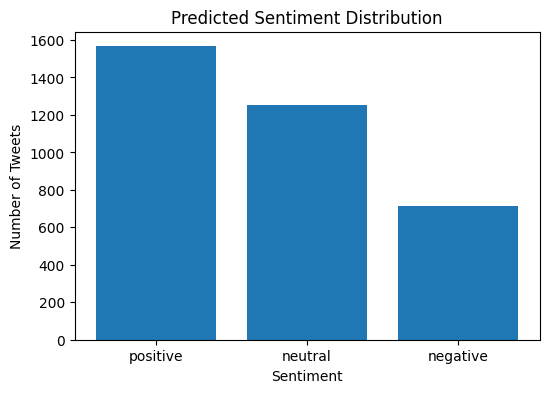

In [4]:
# Import required libraries
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Reviews.csv", encoding="latin1")

# Display first 5 rows
print("Dataset Preview:")
print(df.head())

# Function to classify sentiment
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "positive"
    elif polarity < 0:
        return "negative"
    else:
        return "neutral"

# Predict sentiments using TextBlob
df["Predicted_Sentiment"] = df["text"].apply(get_sentiment)

# Display actual and predicted sentiments
print("\nActual vs Predicted Sentiments:")
print(df[["text", "sentiment", "Predicted_Sentiment"]].head())

# Calculate accuracy
accuracy = (df["sentiment"] == df["Predicted_Sentiment"]).mean() * 100

print(f"\nTextBlob Prediction Accuracy: {accuracy:.2f}%")

# Save the output to a CSV file
df.to_csv("sentiment_results.csv", index=False)

print("\nResults saved successfully as sentiment_results.csv")

# Count predicted sentiments
counts = df["Predicted_Sentiment"].value_counts()

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()